In [10]:
from pathlib import Path

processed = Path("processed")

for split in ["train", "validation", "test"]:
    print(f"\n{split.upper()}")

    for cls in ["drone", "non_drone"]:
        files = list((processed / split / cls).glob("*.npy"))
        print(f"{cls}: {len(files)} files")


TRAIN
drone: 10 files
non_drone: 12 files

VALIDATION
drone: 1 files
non_drone: 1 files

TEST
drone: 2 files
non_drone: 2 files


In [11]:
import numpy as np

sample = np.load(
    "processed/train/drone/DJI_inspire_2_2G.npy"
)

print(sample.shape)
print(sample.dtype)

(58592, 4096)
complex64


In [12]:
from pathlib import Path
import numpy as np

processed = Path("processed")

for file in processed.rglob("*.npy"):

    data = np.load(file)

    assert data.ndim == 2
    assert data.shape[1] == 4096
    assert np.iscomplexobj(data)

print("✓ All processed datasets are valid.")

✓ All processed datasets are valid.


In [13]:
from pathlib import Path
import numpy as np

total = 0

for file in Path("processed").rglob("*.npy"):
    total += np.load(file).shape[0]

print("Total windows:", total)

Total windows: 849566


In [14]:
from pathlib import Path
import numpy as np

for file in Path("processed").rglob("*.npy"):

    windows = np.load(file)

    print(
        file.stem,
        "->",
        windows.shape[0],
        "windows"
    )

DJI_phantom_4_pro_plus_5G_1of2 -> 48827 windows
32274CF-dell-latitude-D20211201T191300M048183 -> 9764 windows
DJI_mavic_pro_2G -> 58592 windows
DJI_phantom_4_2G -> 58592 windows
DJI_phantom_4_pro_plus_2G -> 58592 windows
DJI_matrice_210_2G -> 58592 windows
DJI_inspire_2_2G -> 58592 windows
DJI_inspire_2_5G_1of2 -> 48827 windows
DJI_matrice_210_5G_1of2 -> 48827 windows
DJI_matrice_100_2G -> 58592 windows
DJI_mavic_mini_2G -> 58592 windows
DJI_inspire_2_5G_2of2 -> 48827 windows
32274CA-015-D20211123T131300M012278 -> 9764 windows
32274CF-dell-latitude-D20211125T150800M004475 -> 9764 windows
32274CA-015-D20211123T131500M053479 -> 9764 windows
32274CF-dell-latitude-D20211201T191100M024240 -> 9764 windows
32274CA-015-D20211123T132400M058863 -> 9764 windows
32274CF-dell-latitude-D20211125T152100M004125 -> 9764 windows
32274CF-dell-latitude-D20211125T152000M052549 -> 9764 windows
32274CA-015-D20211123T131400M050226 -> 9764 windows
32274CF-dell-latitude-D20211125T151000M056507 -> 9764 windows
3

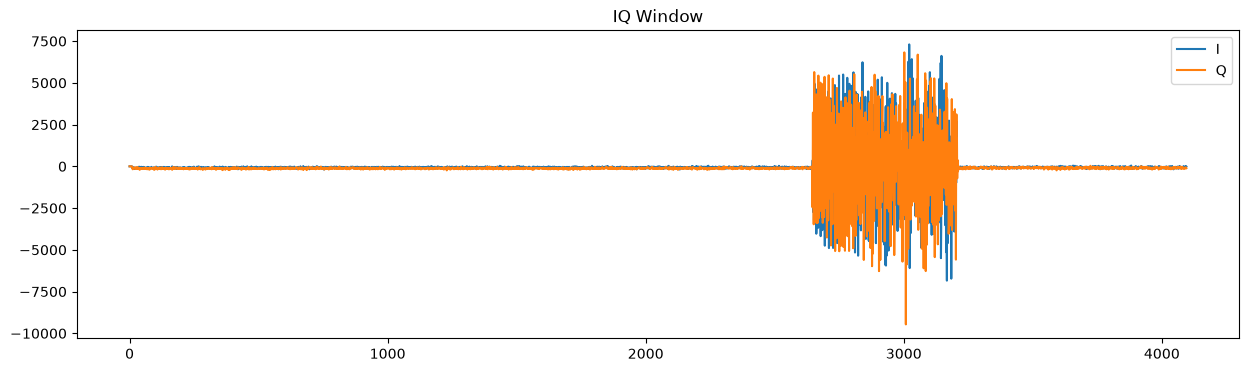

In [17]:
import matplotlib.pyplot as plt
import numpy as np

sample = np.load(
    "processed/train/non_drone/32274CA-015-D20211123T131300M012278.npy"
)

window = sample[0]

plt.figure(figsize=(15,4))
plt.plot(window.real, label="I")
plt.plot(window.imag, label="Q")
plt.legend()
plt.title("IQ Window")
plt.show()

In [18]:
import numpy as np

sample = np.load(
    "processed/train/drone/DJI_inspire_2_2G.npy"
)

print("Real")

print(sample.real.min())
print(sample.real.max())

print()

print("Imaginary")

print(sample.imag.min())
print(sample.imag.max())

Real
-21037.0
20800.0

Imaginary
-20322.0
20962.0


In [19]:
from pathlib import Path
import numpy as np

processed = Path("processed")

for split in ["train", "validation", "test"]:

    print(f"\n{split.upper()}")

    for cls in ["drone", "non_drone"]:

        windows = 0

        files = list((processed / split / cls).glob("*.npy"))

        for file in files:
            windows += np.load(file).shape[0]

        print(
            f"{cls:<12} "
            f"Files: {len(files):<3} "
            f"Windows: {windows}"
        )


TRAIN
drone        Files: 10  Windows: 556625
non_drone    Files: 12  Windows: 117168

VALIDATION
drone        Files: 1   Windows: 48827
non_drone    Files: 1   Windows: 9764

TEST
drone        Files: 2   Windows: 97654
non_drone    Files: 2   Windows: 19528


In [21]:
from training.data_loader import create_dataloaders

train_loader, val_loader, test_loader = create_dataloaders(
    dataset_path="processed",
    batch_size=32,
)

windows, labels = next(iter(train_loader))

print("Windows:", windows.shape)
print("Labels:", labels.shape)

Windows: torch.Size([32, 2, 4096])
Labels: torch.Size([32])


In [22]:
from models.cnn1d import DroneCNN
import torch

model = DroneCNN()
x = torch.randn(32, 2, 4096)
y = model(x)

print(x.shape)
print(y.shape)

torch.Size([32, 2, 4096])
torch.Size([32, 1])
